### WASP-18

In [1]:
import juliet
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.gridspec as gd
import multiprocessing
import matplotlib as mpl
multiprocessing.set_start_method('fork')

mpl.rcParams.update({
    "font.family": "serif",  # Use a serif font for a more professional look
    "font.size": 12,  # Adjust font size for better readability
    "axes.labelsize": 14,  # Label size
    "axes.titlesize": 16,  # Title size
    "xtick.labelsize": 12,  # Tick label size
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 1.5,  # Thicker lines for better visibility
    "axes.linewidth": 1.2,  # Thicker axes lines
    "figure.dpi": 300,  # High-resolution figures
    "savefig.dpi": 300,  # High resolution when saving figures
    "savefig.format": "pdf",  # Save in vector format for publications
    "text.usetex": False  # Use LaTeX for better typography (optional)
})

# print('juliet version: ', juliet.__version__)

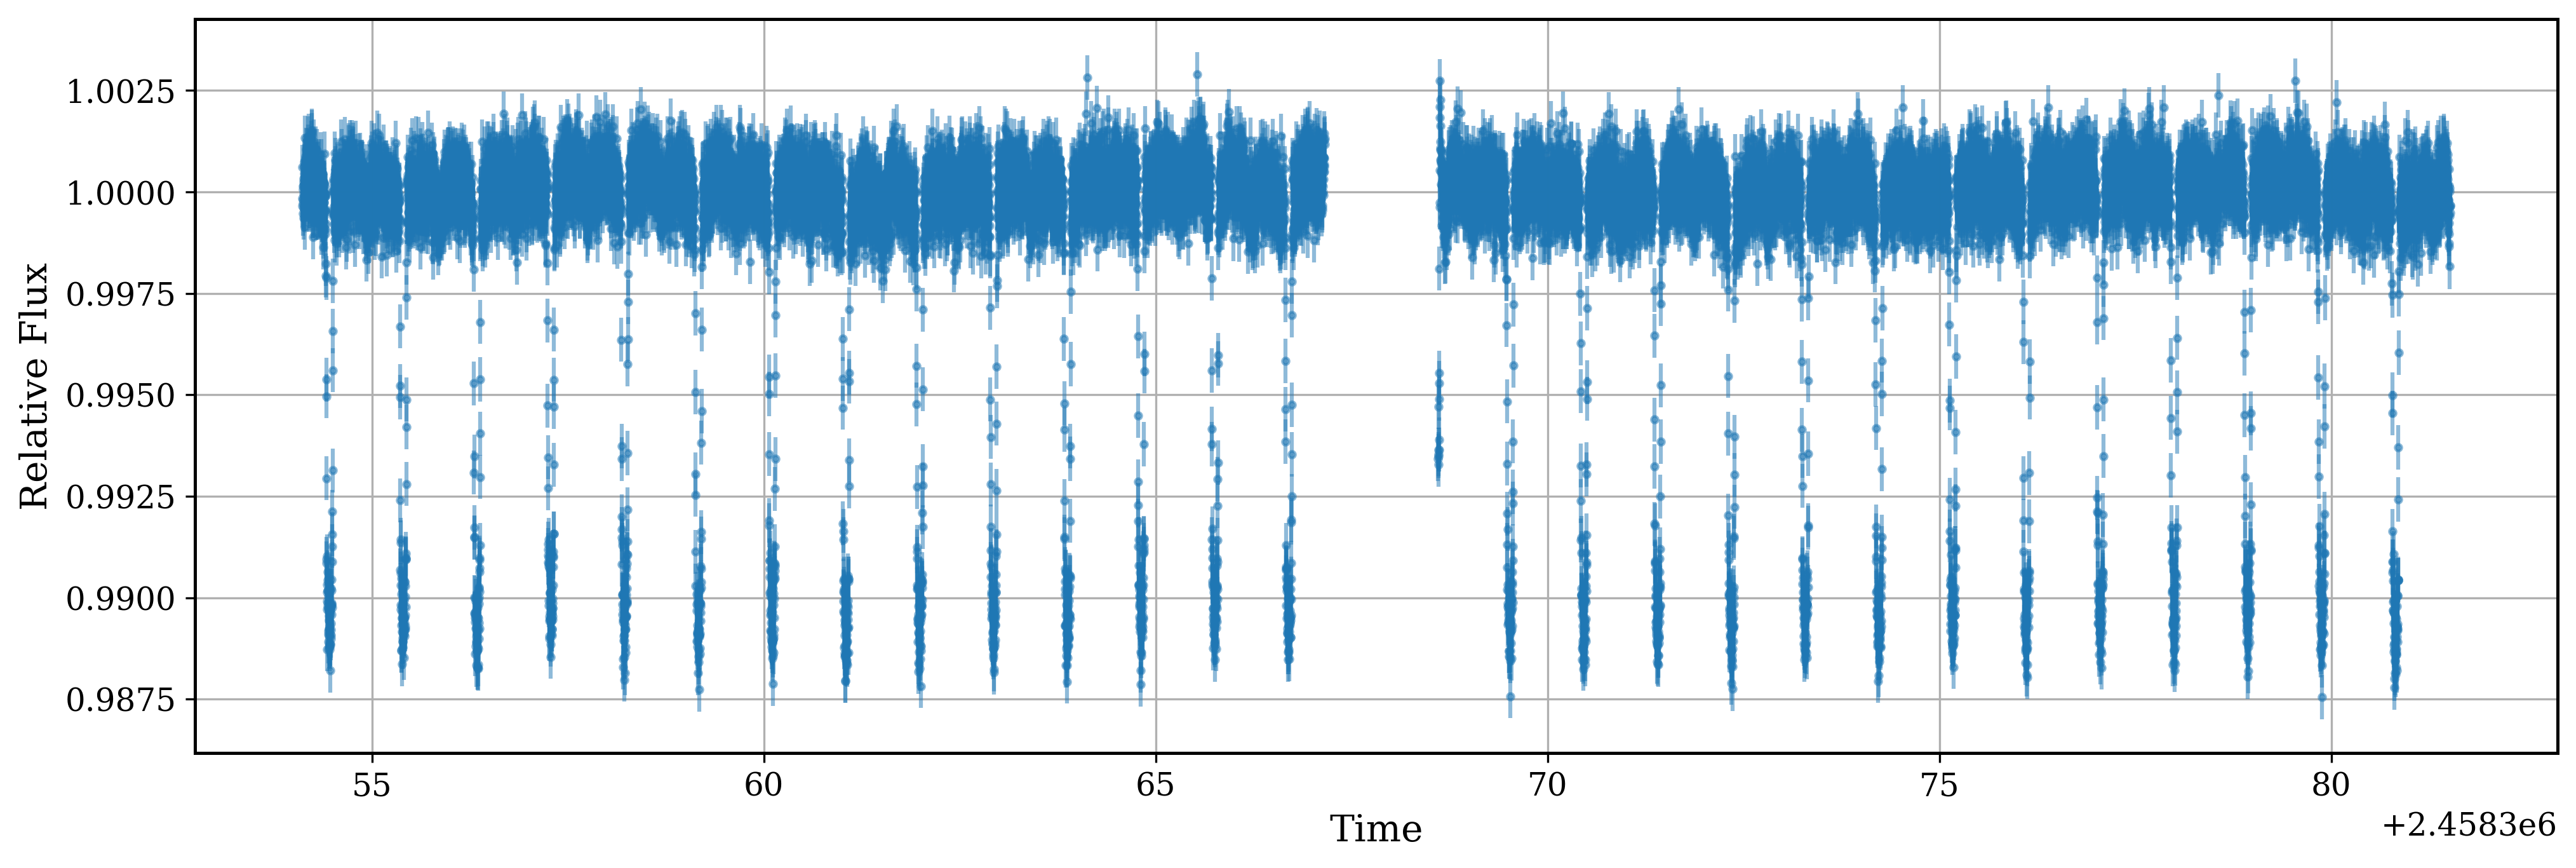

In [53]:
# tim1, fl1, fle1 = np.loadtxt(os.getcwd() + 'WASP-18_TESS2.dat',\
# tim1, fl1, fle1 = np.loadtxt('/Users/surendrabhattarai/Documents/Projects/Exoplanet course (ASTR 575) Project/working/working WASP-18b using juliet/WASP-18_TESS2.dat',\
#     usecols=(0,1,2), unpack=True)

plt.figure(figsize=(16, 5))
# plt.plot(tim1, fl1, '.')
plt.errorbar(tim1, fl1, yerr=fle1, fmt='.', alpha=0.5)
# plt.errorbar(tim1, fl1, yerr=fle1, fmt='.')
plt.xlabel('Time')
plt.ylabel('Relative Flux')
plt.grid()

In [3]:
tim, fl, fle = {}, {}, {}
tim['TESS2'], fl['TESS2'], fle['TESS2'] = tim1, fl1, fle1

### Below we model the lightcurve assuming eccentric orbit (i.e., by giving non-zero ecc). Later on, we will also try to model with circular orbit see if the parameters are more consistent with e=0

In [5]:
# putting parameters of WASP-18b from literature

per, per_err = 0.94145223, 0.00000024    
bjd0, bjd0_err = 2456740.80560, 0.00019

cycle = round((tim1[-1] - bjd0)/per)
tc1 = np.random.normal(bjd0, bjd0_err, 100000) + cycle*np.random.normal(per, per_err, 100000)
tc0, tc0_err = np.median(tc1), np.std(tc1)


tc2 = tc1 + np.random.normal(per, per_err, 100000)/2    ## eclipse time
tc_ecl, tc_ecl_err = np.median(tc2), np.std(tc2)

# Priors    #worked
par_P = ['P_p1', 't0_p1', 'p_p1_TESS2', 'b_p1', 'q1_TESS2', 'q2_TESS2',\
     'a_p1', 'fp_p1_TESS2', 't_secondary_p1', 'ecc_p1', 'omega_p1']
dist_P = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform',\
     'loguniform', 'uniform', 'normal', 'uniform', 'uniform']
hyper_P = [[per, per_err], [tc0, 0.1], [0., 1.], [0., 1.], [0.,1.], [0.,1.],\
     [1., 10.], [0.e-6, 500.e-6], [tc_ecl, tc_ecl_err], [0., 0.1], [0., 360.0]]

##########   # debugging
# par_P = ['P_p1', 't0_p1', 'p_p1_TESS2', 'b_p1', 'q1_TESS2', 'q2_TESS2',
#          'a_p1', 'fp_p1_TESS2', 't_secondary_p1', 'sesinw_p1', 'secosw_p1']
# dist_P = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform',
#           'loguniform', 'uniform', 'normal', 'uniform', 'uniform']
# hyper_P = [[per, per_err], [tc0, 0.1], [0., 1.], [0., 1.], [0., 1.], [0., 1.],
#            [1., 10.], [0.e-6, 500.e-6], [tc_ecl, tc_ecl_err], [-0.3, 0.3], [-0.3, 0.3]]
###########

par_ins = ['mdilution_TESS2', 'mflux_TESS2', 'sigma_w_TESS2']
dist_ins = ['fixed', 'normal', 'loguniform']
hyper_ins = [1., [0., 0.1], [0.1, 10000.]]

par_gp = ['GP_sigma_TESS2', 'GP_timescale_TESS2', 'GP_rho_TESS2']
dist_gp = ['loguniform', 'loguniform', 'loguniform']
hyper_gp = [[1e-5, 10000.], [1e-3, 1e2], [1e-3, 1e2]]

par_tot = par_P + par_ins + par_gp
dist_tot = dist_P + dist_ins + dist_gp
hyper_tot = hyper_P + hyper_ins + hyper_gp

priors_tot = juliet.utils.generate_priors(par_tot, dist_tot, hyper_tot)

In [6]:
# Fitting

# 
# dataset = juliet.load(priors=priors_tot, t_lc=tim, y_lc=fl, yerr_lc=fle,\
#     GP_regressors_lc=tim, out_folder=os.getcwd() + '/Analysis/Transit-Eclipse')
# res = dataset.fit(sampler = 'dynesty', nthreads=8)

dataset = juliet.load(priors=priors_tot, t_lc=tim, y_lc=fl, yerr_lc=fle,
                      GP_regressors_lc=tim, out_folder=os.getcwd() + '/Juliet_Analysis/Transit-Eclipse-ecc')
res = dataset.fit(sampler='dynesty', nthreads=8, verbose=True)

25211it [16:18, 25.76it/s, +500 | bound: 299 | nc: 1 | ncall: 869488 | eff(%):  2.959 | loglstar:   -inf < 111448.525 <    inf | logz: 111398.645 +/-  0.317 | dlogz:  0.001 >  0.509]


In [ ]:
os.system("cat Juliet_Analysis/Transit-Eclipse-ecc/posteriors.dat")

# Parameter Name     	 	 Median       	 	 Upper 68 CI  	 	 Lower 68 CI 
P_p1               	 	 0.9414523009 	 	 0.0000001677 	 	 0.0000001308
t0_p1              	 	 2458381.7599596120 	 	 0.0000884198 	 	 0.0000666534
p_p1_TESS2         	 	 0.0981963283 	 	 0.0003584804 	 	 0.0005798273
b_p1               	 	 0.4088400707 	 	 0.0157124504 	 	 0.0189183776
q1_TESS2           	 	 0.2073960416 	 	 0.0236716153 	 	 0.0229201624
q2_TESS2           	 	 0.3302837734 	 	 0.0527991271 	 	 0.0460014570
a_p1               	 	 3.3499090863 	 	 0.0630850377 	 	 0.0605149143
fp_p1_TESS2        	 	 0.0003313071 	 	 0.0000254754 	 	 0.0000182999
t_secondary_p1     	 	 2458382.2278648973 	 	 0.0006054733 	 	 0.0003063791
ecc_p1             	 	 0.0416972835 	 	 0.0145270029 	 	 0.0158058578
omega_p1           	 	 135.6101403185 	 	 35.3305953356 	 	 61.5677477299
mflux_TESS2        	 	 -0.0006623400 	 	 0.0039971511 	 	 0.0072454467
sigma_w_TESS2      	 	 9.1168899322 	 	 8.8893015999 	 	 5.1730000537
G

0

P_sigma_TESS2     	 	 0.0000405411 	 	 0.0000210698 	 	 0.0000162838
GP_timescale_TESS2 	 	 0.0077377933 	 	 0.0048434886 	 	 0.0024753167
GP_rho_TESS2       	 	 49.1257301666 	 	 23.8118583974 	 	 23.4044272643


## Uncertainty estimation (for ecc case)

It is seen that the posteriors (table shown above) look good for most of the planetary parameters and seems to agree with their corresponding values from the literature.
As we will see below, the parameters seem to agree more with ecc case compared to circular case.

In [7]:
# Making model
model = res.lc.evaluate('TESS2')
gp_model = res.lc.model['TESS2']['GP']
transit_model = res.lc.model['TESS2']['deterministic']
mflx = np.median(res.posteriors['posterior_samples']['mflux_TESS2'])
sigw = np.median(res.posteriors['posterior_samples']['sigma_w_TESS2'] * 1e-6)

(2458354.1115072616, 2458381.5174589776)

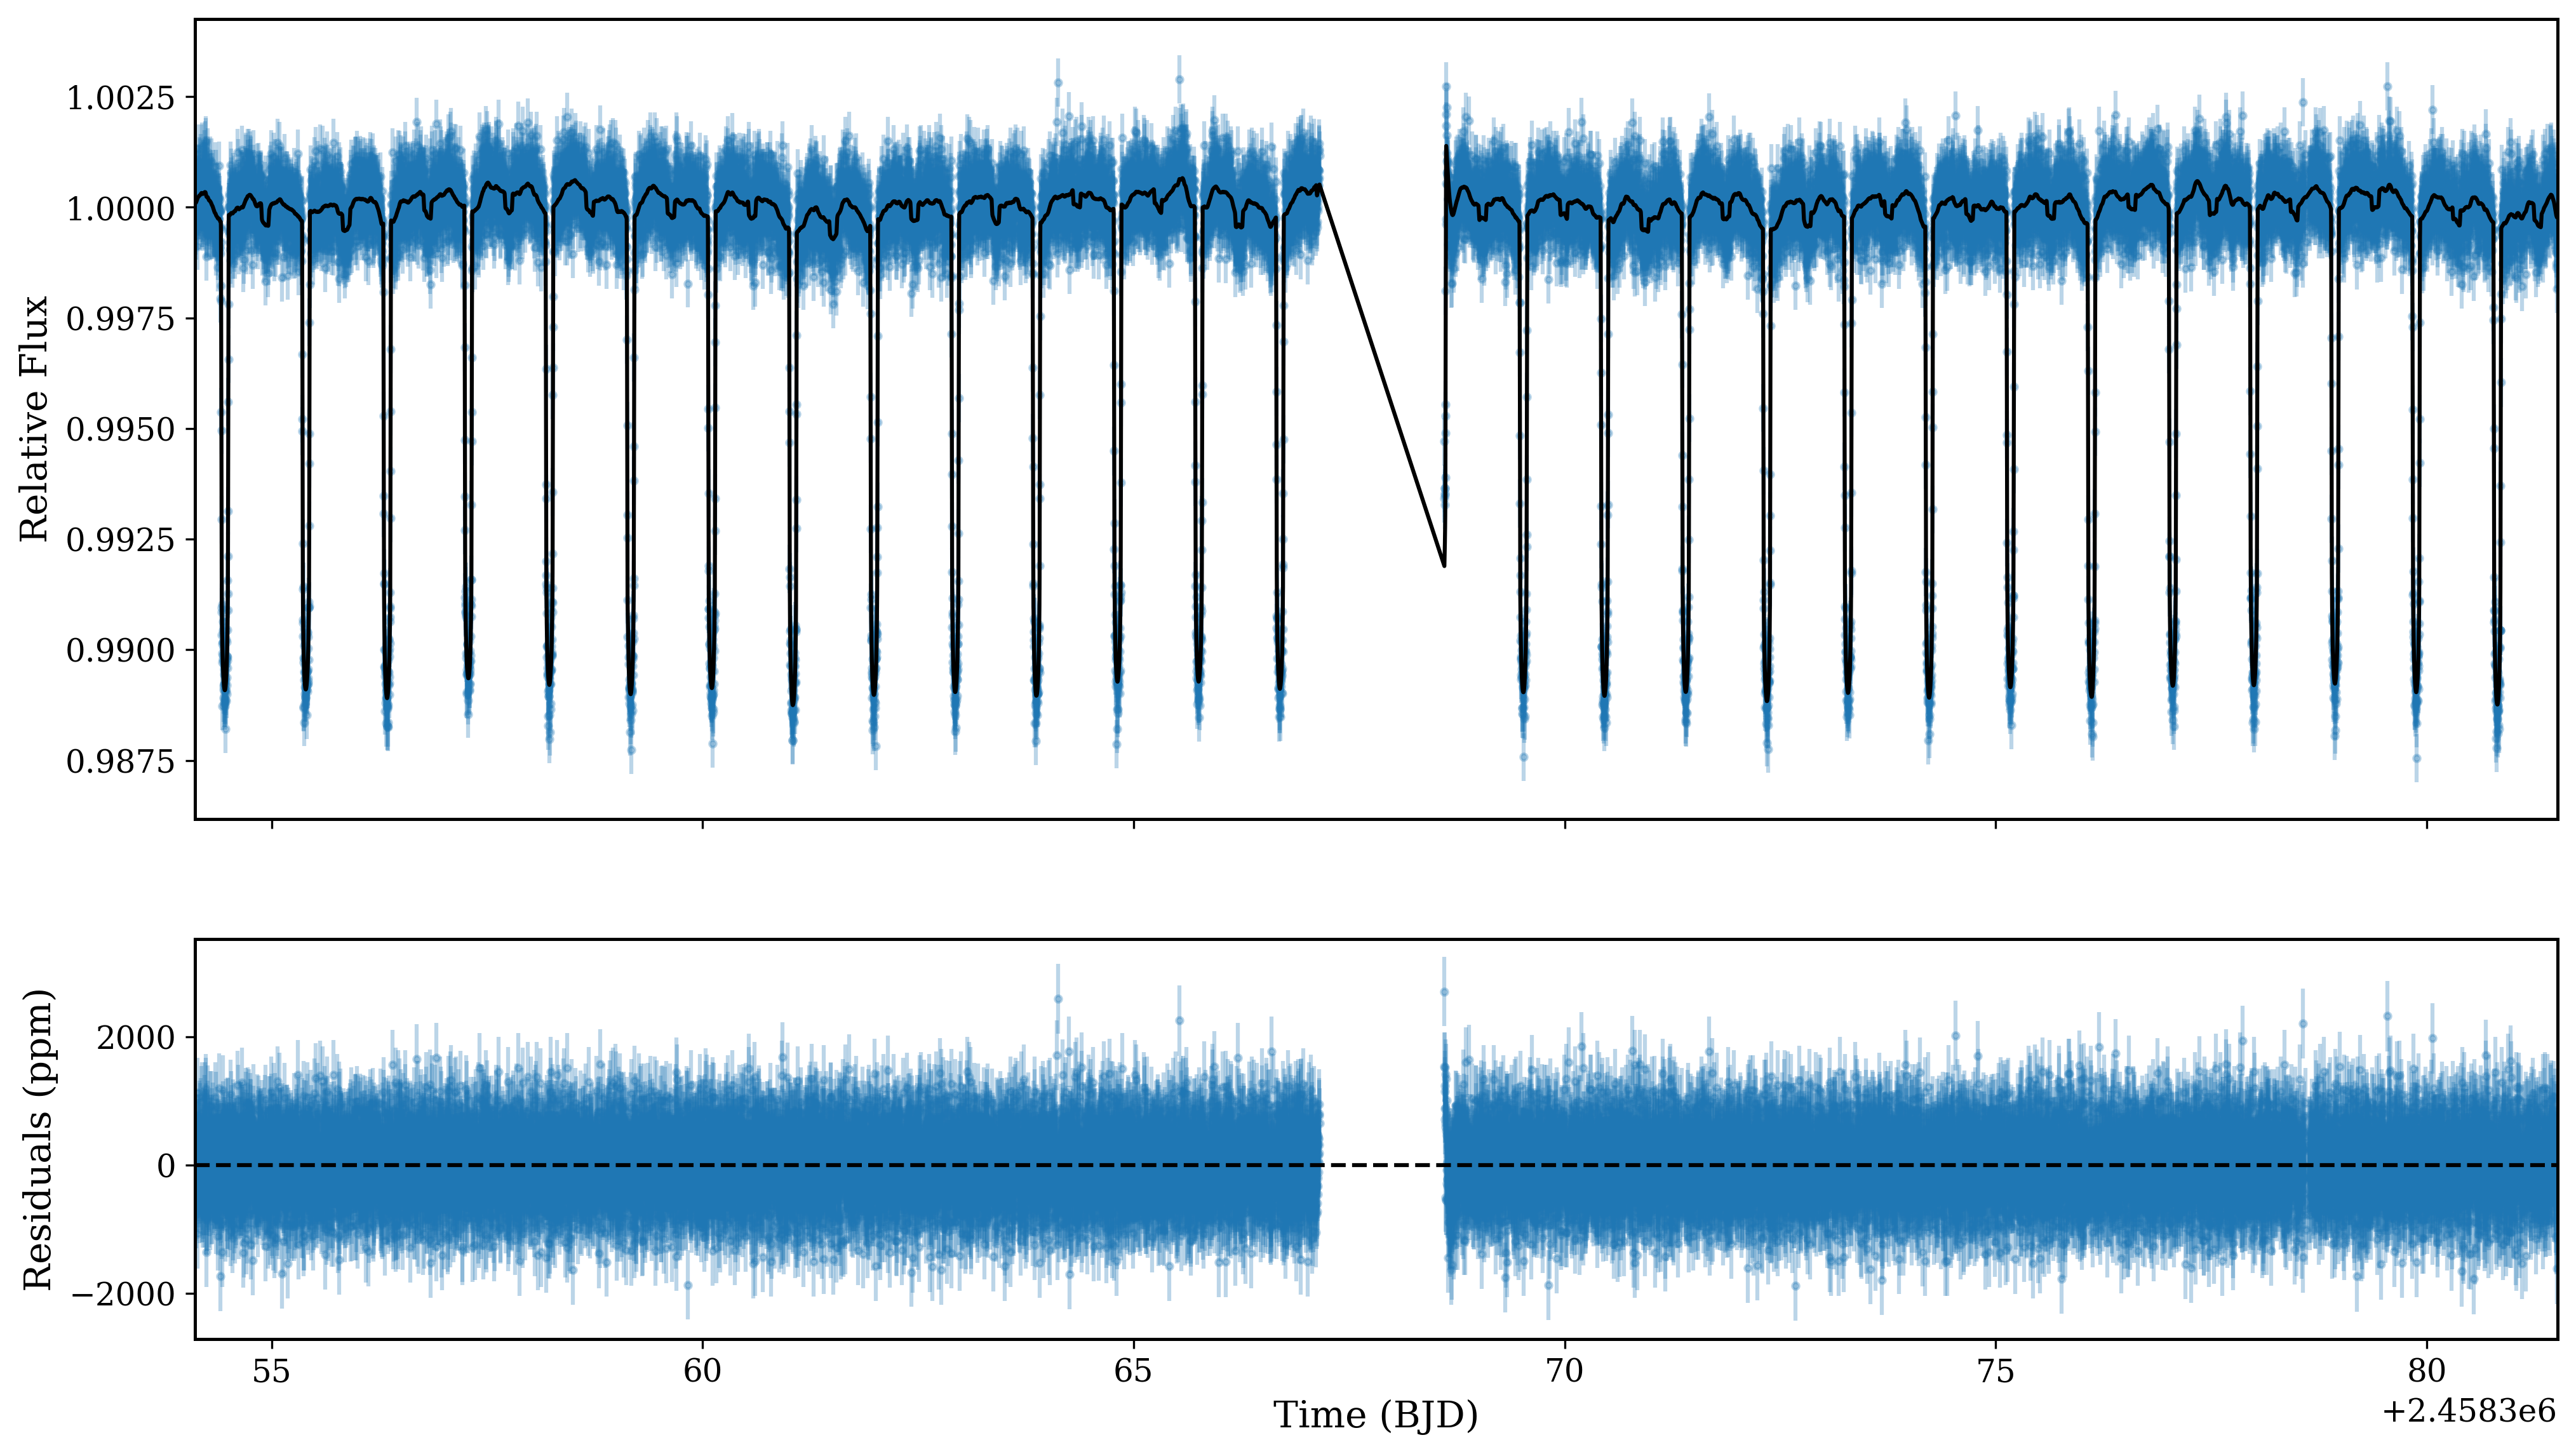

In [8]:
fig = plt.figure(figsize=(16,9))
gs = gd.GridSpec(2,1, height_ratios=[2,1])

# Lightcurve
ax1 = plt.subplot(gs[0])
ax1.errorbar(tim['TESS2'], fl['TESS2'], yerr=fle['TESS2'], fmt='.', alpha=0.3)
ax1.plot(tim['TESS2'], model, c='k', zorder=100)
ax1.set_ylabel('Relative Flux')
ax1.set_xlim(np.min(tim['TESS2']), np.max(tim['TESS2']))
ax1.xaxis.set_major_formatter(plt.NullFormatter())
# fig.suptitle("WASP-18")

# Residual
ax2 = plt.subplot(gs[1])
ax2.errorbar(tim['TESS2'], (fl['TESS2']-model)*1e6, yerr=fle['TESS2']*1e6, fmt='.', alpha=0.3)
ax2.axhline(y=0.0, c='black', ls='--', zorder=100)
ax2.set_ylabel('Residuals (ppm)')
ax2.set_xlabel('Time (BJD)')
ax2.set_xlim(np.min(tim['TESS2']), np.max(tim['TESS2']))

### Zooming in  (assuming ecc)

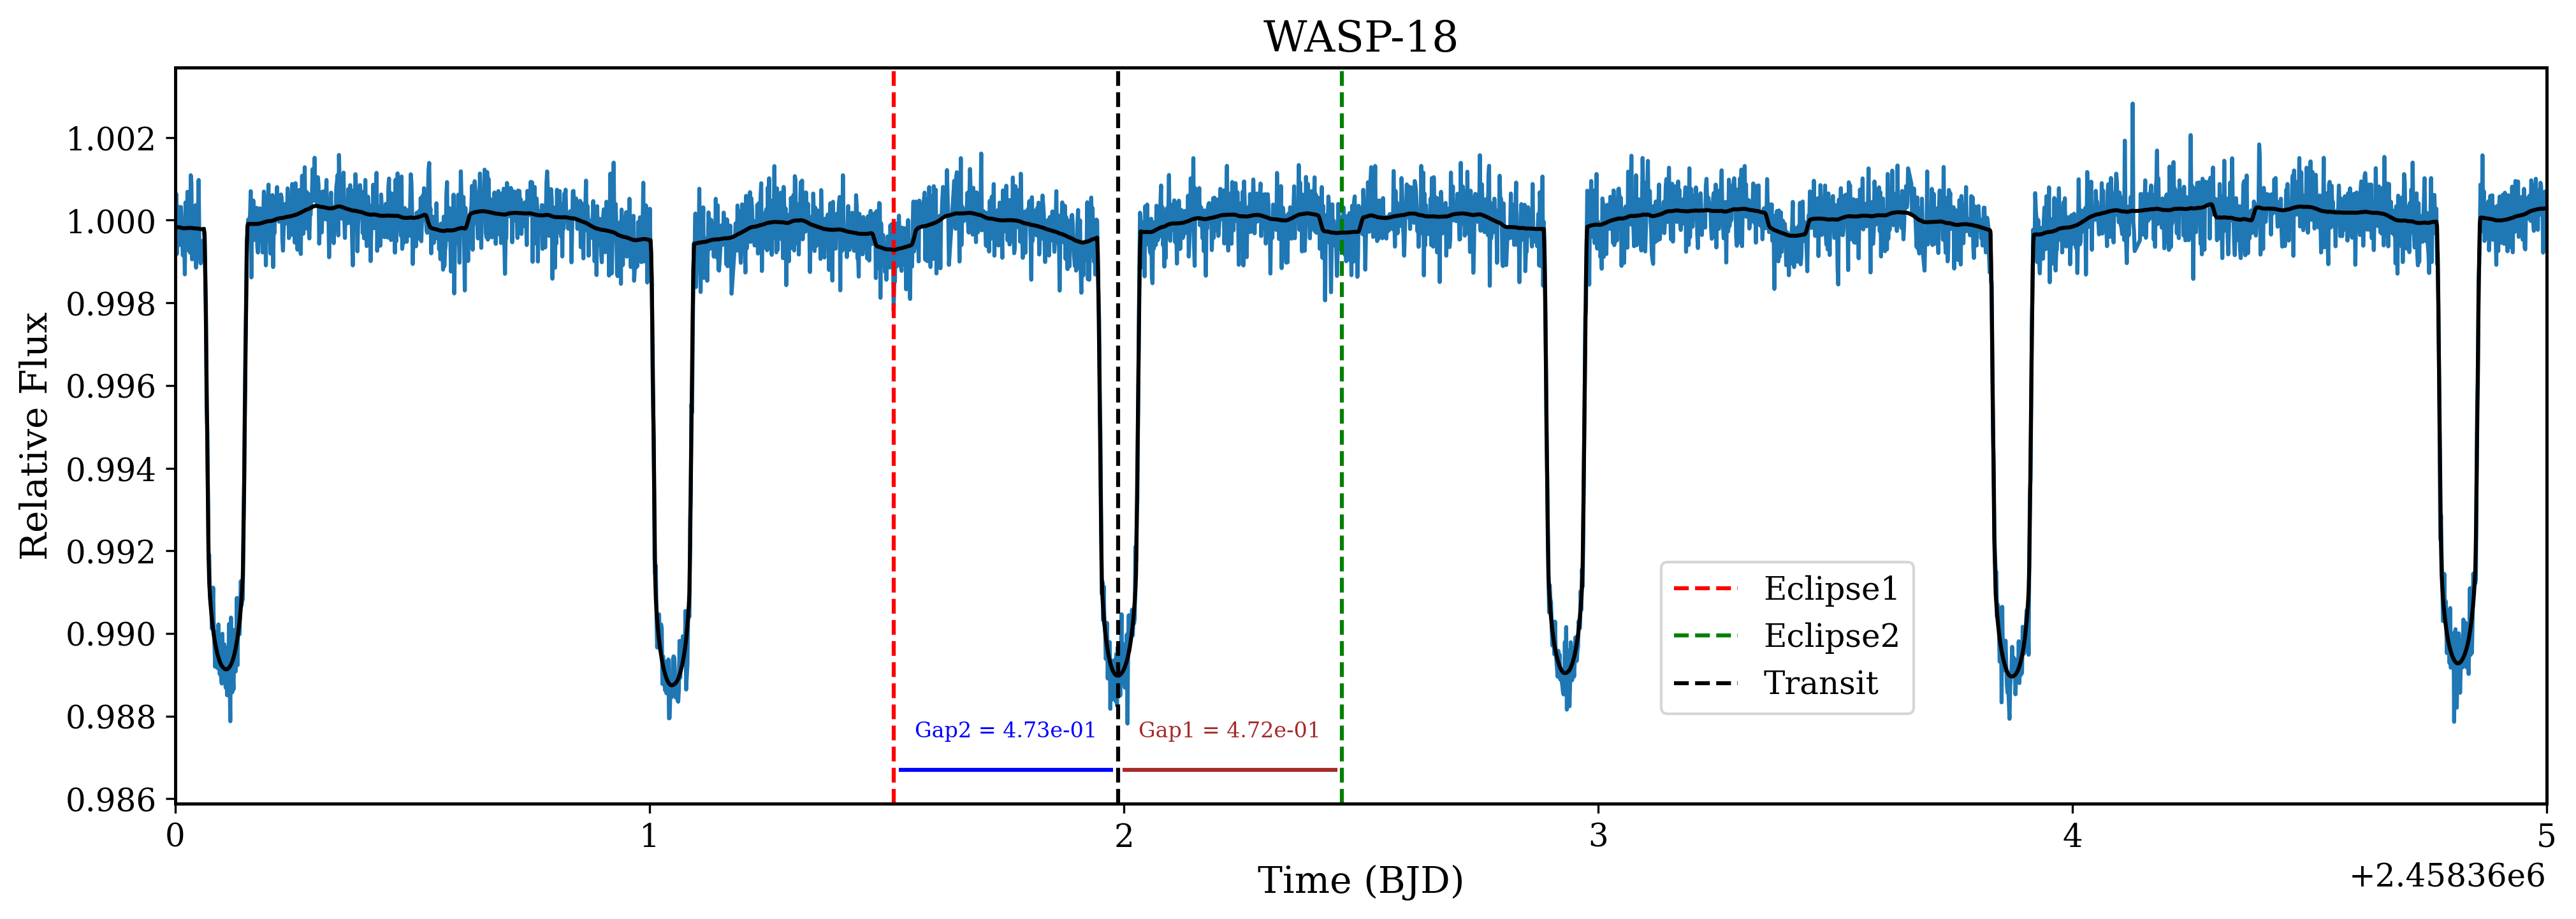

In [9]:
plt.figure(figsize=(16,5))
plt.plot(tim['TESS2'], model, c='k', zorder=100)
plt.plot(tim['TESS2'], fl['TESS2'])#, '.') #, yerr=fle['TESS2'], fmt='.', alpha=0.3)

tr1 = 1.9875 + 2.45836e6   # Transit
x1 = 1.515 + 2.45836e6  # Eclipse1
x2 = 2.46 + 2.45836e6   # Eclipse2
# xt = (x2 - x1)/2
y_gap2 = x2 - x1  # Choose a suitable y-coordinate for the horizontal line

gap1 = tr1 - x1
gap2 = x2 - tr1

# Plot vertical lines
plt.axvline(x=x1, color='red', linestyle='--', label="Eclipse1")
plt.axvline(x=x2, color='green', linestyle='--', label="Eclipse2")
plt.axvline(x=tr1, color='black', linestyle='--', label="Transit")

plt.hlines(y=0.9867, xmin=x1+0.01, xmax=tr1-0.01, color='blue', linestyle='-')#, label="Gap")
plt.text((x1 + tr1 ) / 2, 0.9865 + 0.001, f"Gap2 = {gap2:.2e}", color='blue', ha='center', fontsize=8)

plt.hlines(y=0.9867, xmin=tr1+0.01, xmax=x2-0.01, color='brown', linestyle='-')#, label="Gap")
plt.text((tr1 + x2) / 2, 0.9865 + 0.001, f"Gap1 = {gap1:.2e}", color='brown', ha='center', fontsize=8)

plt.xlim(60 + 2.4583e6, 65+ 2.4583e6)
plt.legend(loc="lower left", bbox_to_anchor=(0.62, 0.1))
plt.ylabel('Relative Flux')
plt.xlabel('Time (BJD)')
plt.title("WASP-18")
plt.show()

In [77]:
period = 0.9414523009 #   taken from the posterior obtained
x1 = 1.515 + 2.45836e6  # Eclipse1
x2 = 2.46 + 2.45836e6   # Eclipse2
# xt = (x2 - x1)/2
# y_gap2 = x2 - x1  # Choose a suitable y-coordinate for the horizontal line
tr1 = 1.9875 + 2.45836e6   # Transit
gap1 = tr1 - x1
gap2 = x2 - tr1
e_cos_w = np.pi * (gap1/(2*period) - 1/4)
w = 135.6101403185 # taken from posterior
e = abs(e_cos_w / np.cos(w*np.pi/180))
print(f'e cos w = {e_cos_w}')     # 0.005919381140840311 (non zero ecc prior)  0.014261793666957933 (fixed 0 ecc)    
print(f'e = {e}')                 # 0.00634345104845027  (non zero ecc prior)  0.16363573090358577 (fixed 0 ecc)      
                                  # 0.00510 (Cortés-Zuleta et al. 2020),     0.00910 (Kokori et al. 2023)

e cos w = 0.002959635721715286
e = 0.004141687983869024


### Phase-folded lightcurve:

(-0.1, 0.6)

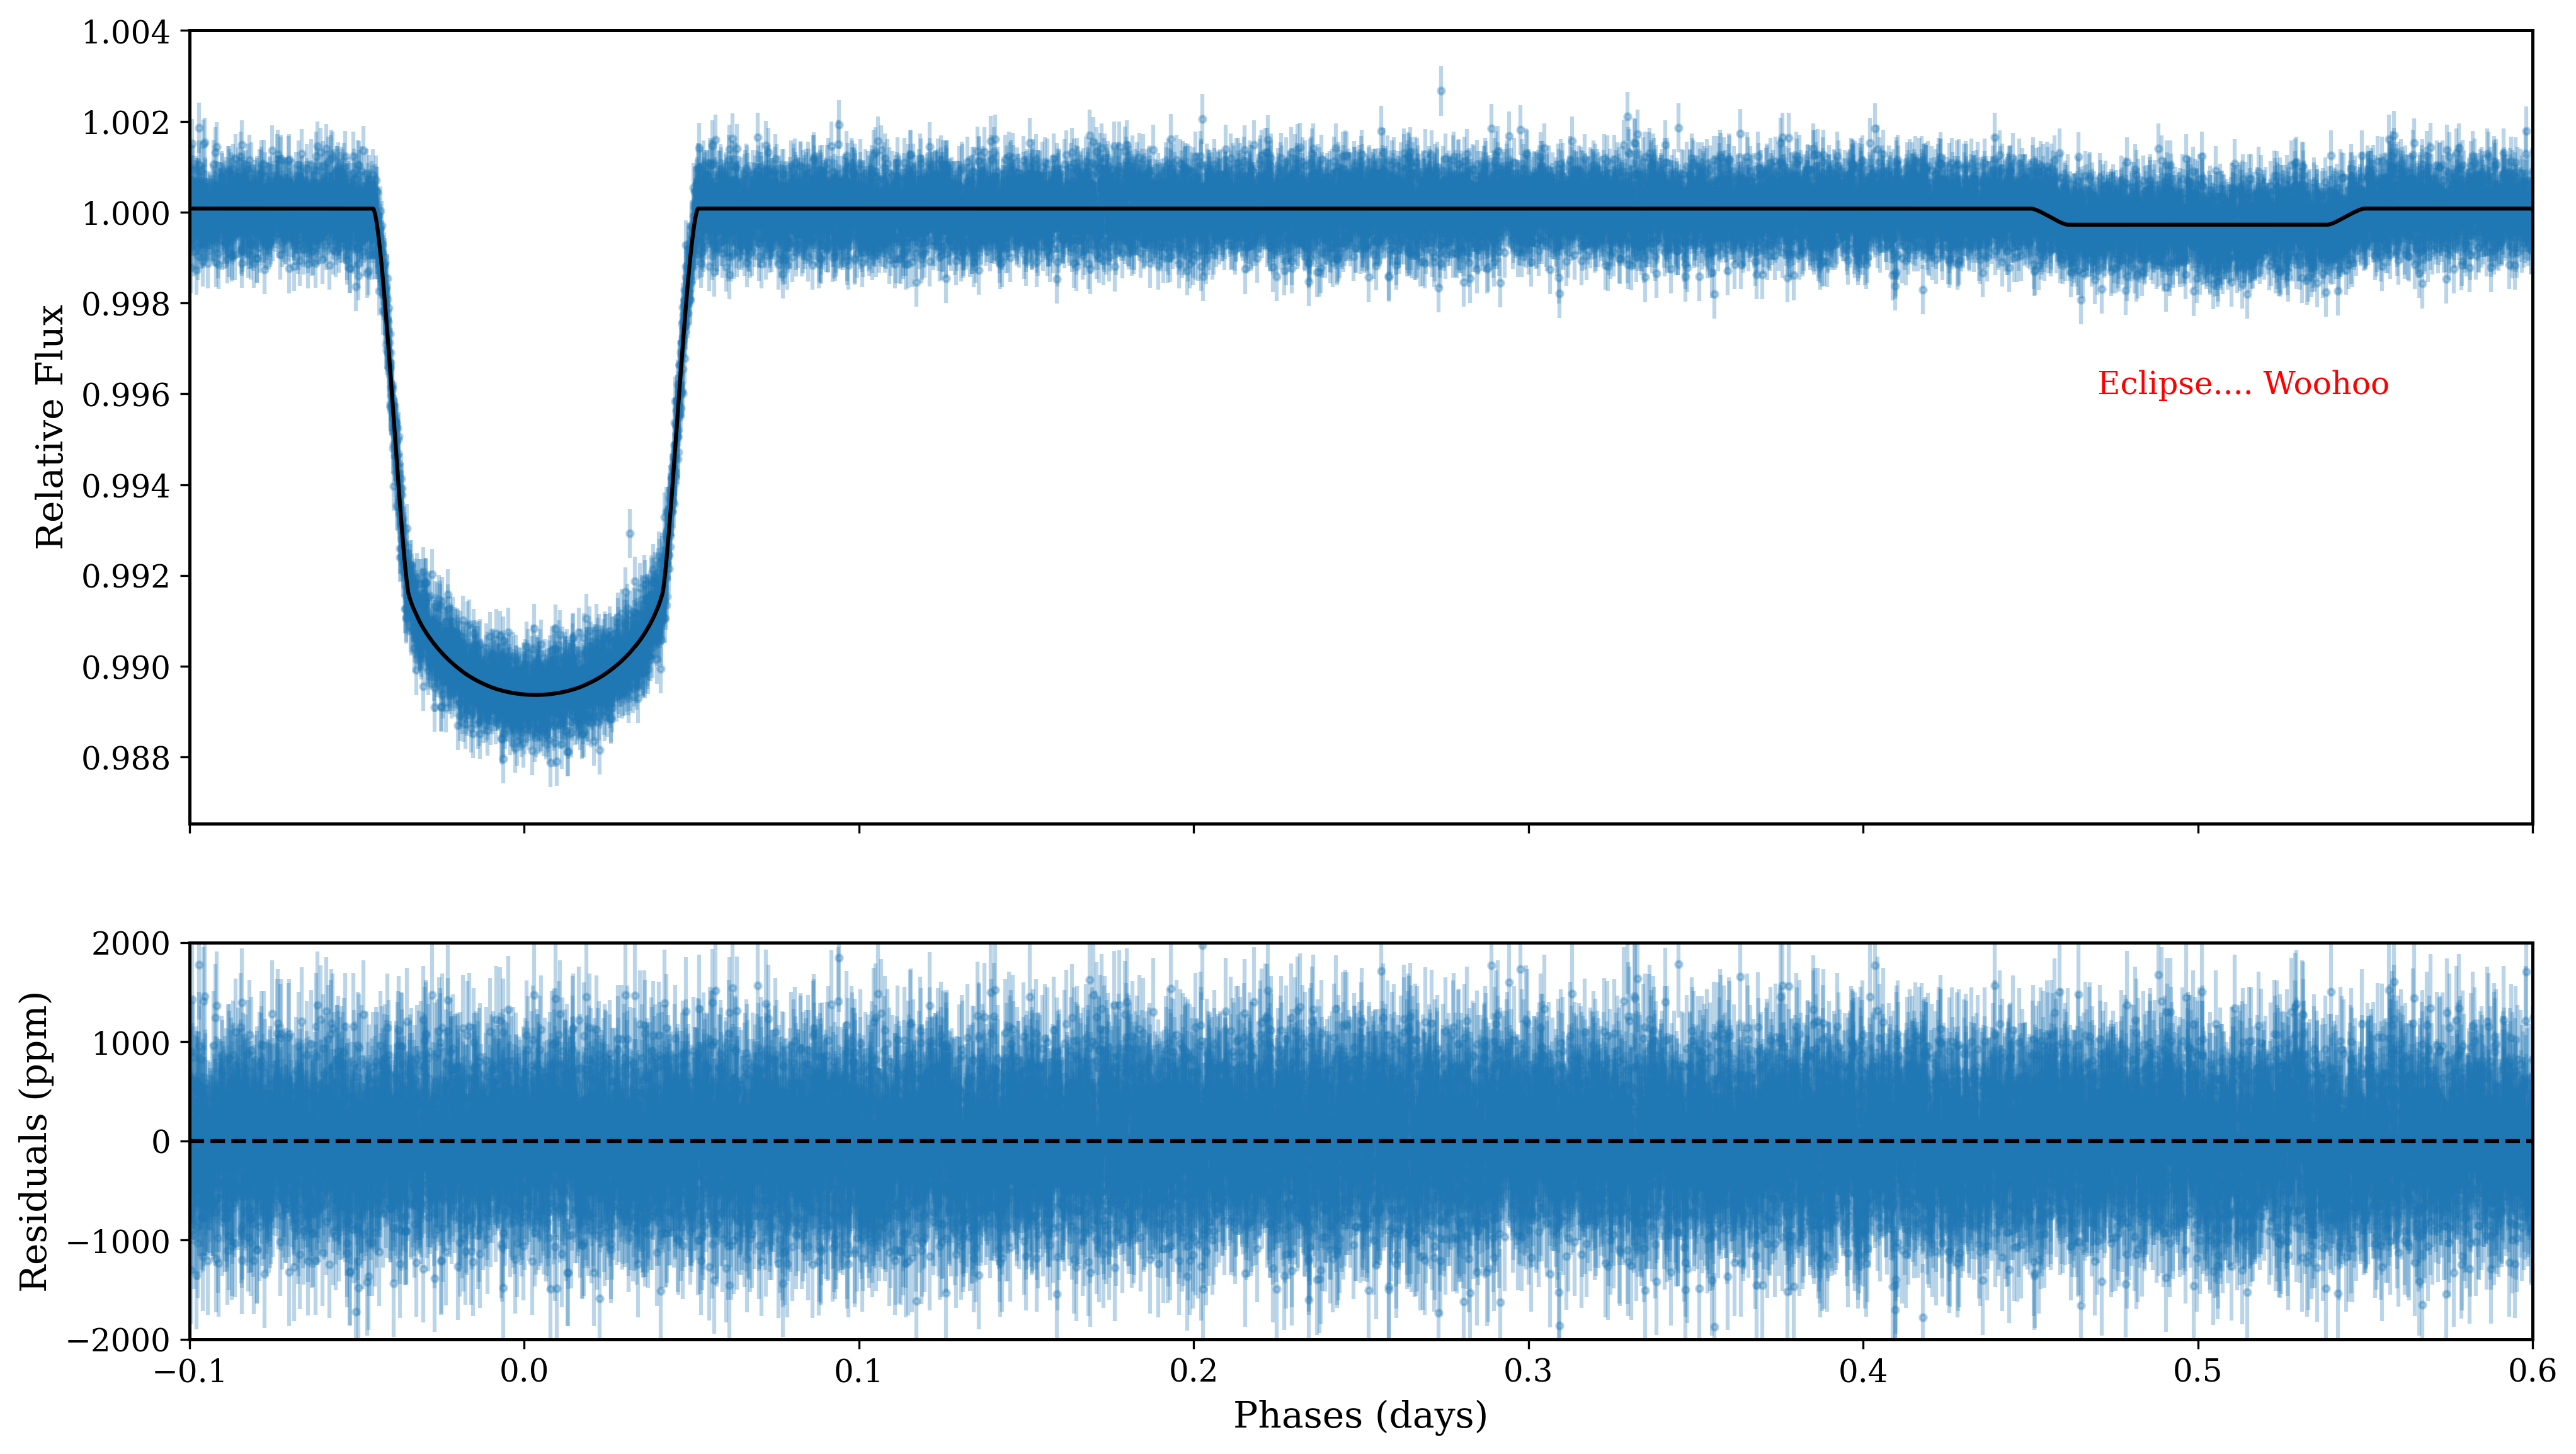

In [48]:
phs = juliet.utils.get_phases(tim['TESS2'], per, bjd0, phmin=0.8)
idx = np.argsort(phs)

fig = plt.figure(figsize=(16,9))
gs = gd.GridSpec(2,1, height_ratios=[2,1])


ax1 = plt.subplot(gs[0])
ax1.errorbar(phs, (fl['TESS2']-gp_model) * (1 + mflx), yerr=np.sqrt(fle['TESS2']**2 + sigw**2),\
             fmt='.', alpha=0.3)
ax1.plot(phs[idx], transit_model[idx] * (1 + mflx), c='k', zorder=100)
ax1.text(0.47, 0.996, "Eclipse.... Woohoo", fontsize=12, color='red')
ax1.set_ylabel('Relative Flux')
ax1.set_xlim(-0.1, 0.6)
#ax1.set_ylim(0.998, 1.002)
ax1.xaxis.set_major_formatter(plt.NullFormatter())


ax2 = plt.subplot(gs[1])
ax2.errorbar(phs, (fl['TESS2']-model)*1e6, yerr=np.sqrt(fle['TESS2']**2 + sigw**2) * 1e6,\
             fmt='.', alpha=0.3)
ax2.axhline(y=0.0, c='black', ls='--', zorder=100)
ax2.set_ylabel('Residuals (ppm)')
ax2.set_xlabel('Phases (days)')
ax2.set_ylim(-2000, 2000)
ax2.set_xlim(-0.1, 0.6)

## Now trying circular model to see if the parameters are more consistent with e=0

In [29]:
# Priors   

par_P = ['P_p1', 't0_p1', 'p_p1_TESS2_TESS3', 'b_p1', 'q1_TESS2_TESS3', 'q2_TESS2_TESS3',\
     'a_p1', 'fp_p1_TESS2_TESS3', 't_secondary_p1', 'ecc_p1', 'omega_p1']
dist_P = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform',\
     'loguniform', 'uniform', 'normal', 'fixed', 'fixed']
hyper_P = [[per, per_err], [tc0, 0.1], [0., 1.], [0., 1.], [0.,1.], [0.,1.],\
     [1., 10.], [0.e-6, 500.e-6], [tc_ecl, 0.1], 0., 90.]

par_ins = ['mdilution_TESS2', 'mflux_TESS2', 'sigma_w_TESS2']
dist_ins = ['fixed', 'normal', 'loguniform']
hyper_ins = [1., [0., 0.1], [0.1, 10000.]]

par_gp = ['GP_sigma_TESS2', 'GP_timescale_TESS2', 'GP_rho_TESS2']
dist_gp = ['loguniform', 'loguniform', 'loguniform']
hyper_gp = [[1e-5, 10000.], [1e-3, 1e2], [1e-3, 1e2]]

par_tot = par_P + par_ins + par_gp
dist_tot = dist_P + dist_ins + dist_gp
hyper_tot = hyper_P + hyper_ins + hyper_gp

priors_tot = juliet.utils.generate_priors(par_tot, dist_tot, hyper_tot)

In [30]:
# fitting
dataset = juliet.load(priors=priors_tot, t_lc=tim, y_lc=fl, yerr_lc=fle,\
    GP_regressors_lc=tim, out_folder=os.getcwd() + '/Analysis_assuming_circular/Transit-Eclipse')
res = dataset.fit(sampler = 'dynesty', nthreads=8)

Detected dynesty sampler output files --- extracting from /Users/surendrabhattarai/Documents/Projects/Exoplanet course (ASTR 575) Project/working/working WASP-18b/Analysis_assuming_circular/Transit-Eclipse/_dynesty_NS_posteriors.pkl


In [31]:
os.system("cat Analysis_assuming_circular/Transit-Eclipse/posteriors.dat")

# Parameter Name     	 	 Median       	 	 Upper 68 CI  	 	 Lower 68 CI 
P_p1               	 	 0.9414522576 	 	 0.0000002380 	 	 0.0000002437
t0_p1              	 	 2458381.7600118862 	 	 0.0000335509 	 	 0.0000325558
p_p1_TESS2_TESS3   	 	 0.0981903193 	 	 0.0004182804 	 	 0.0004107000
b_p1               	 	 0.4056831004 	 	 0.0209664423 	 	 0.0228151754
q1_TESS2_TESS3     	 	 0.2065856505 	 	 0.0338135224 	 	 0.0322703705
q2_TESS2_TESS3     	 	 0.3395840700 	 	 0.0826609784 	 	 0.0642492028
a_p1               	 	 3.4287316958 	 	 0.0297953793 	 	 0.0289974755
fp_p1_TESS2_TESS3  	 	 0.0003642300 	 	 0.0000266793 	 	 0.0000271761
t_secondary_p1     	 	 2458382.2309087524 	 	 0.0006910982 	 	 0.0007153787
mflux_TESS2        	 	 0.0003328829 	 	 0.0047732270 	 	 0.0041964725
sigma_w_TESS2      	 	 1.4901984356 	 	 7.8154951521 	 	 1.2582386544
GP_sigma_TESS2     	 	 0.0000239238 	 	 0.0000509657 	 	 0.0000111726
GP_timescale_TESS2 	 	 0.0128408069 	 	 0.0114127431 	 	 0.0086718614
GP_rho

0

## Uncertainty estimation (for circular case)

It is seen that the posteriors (table shown above) look good, but not better than the ecc case above. 
#### So, it can be safely said that the ecc case fits the data better

(2458354.1115072616, 2458381.5174589776)

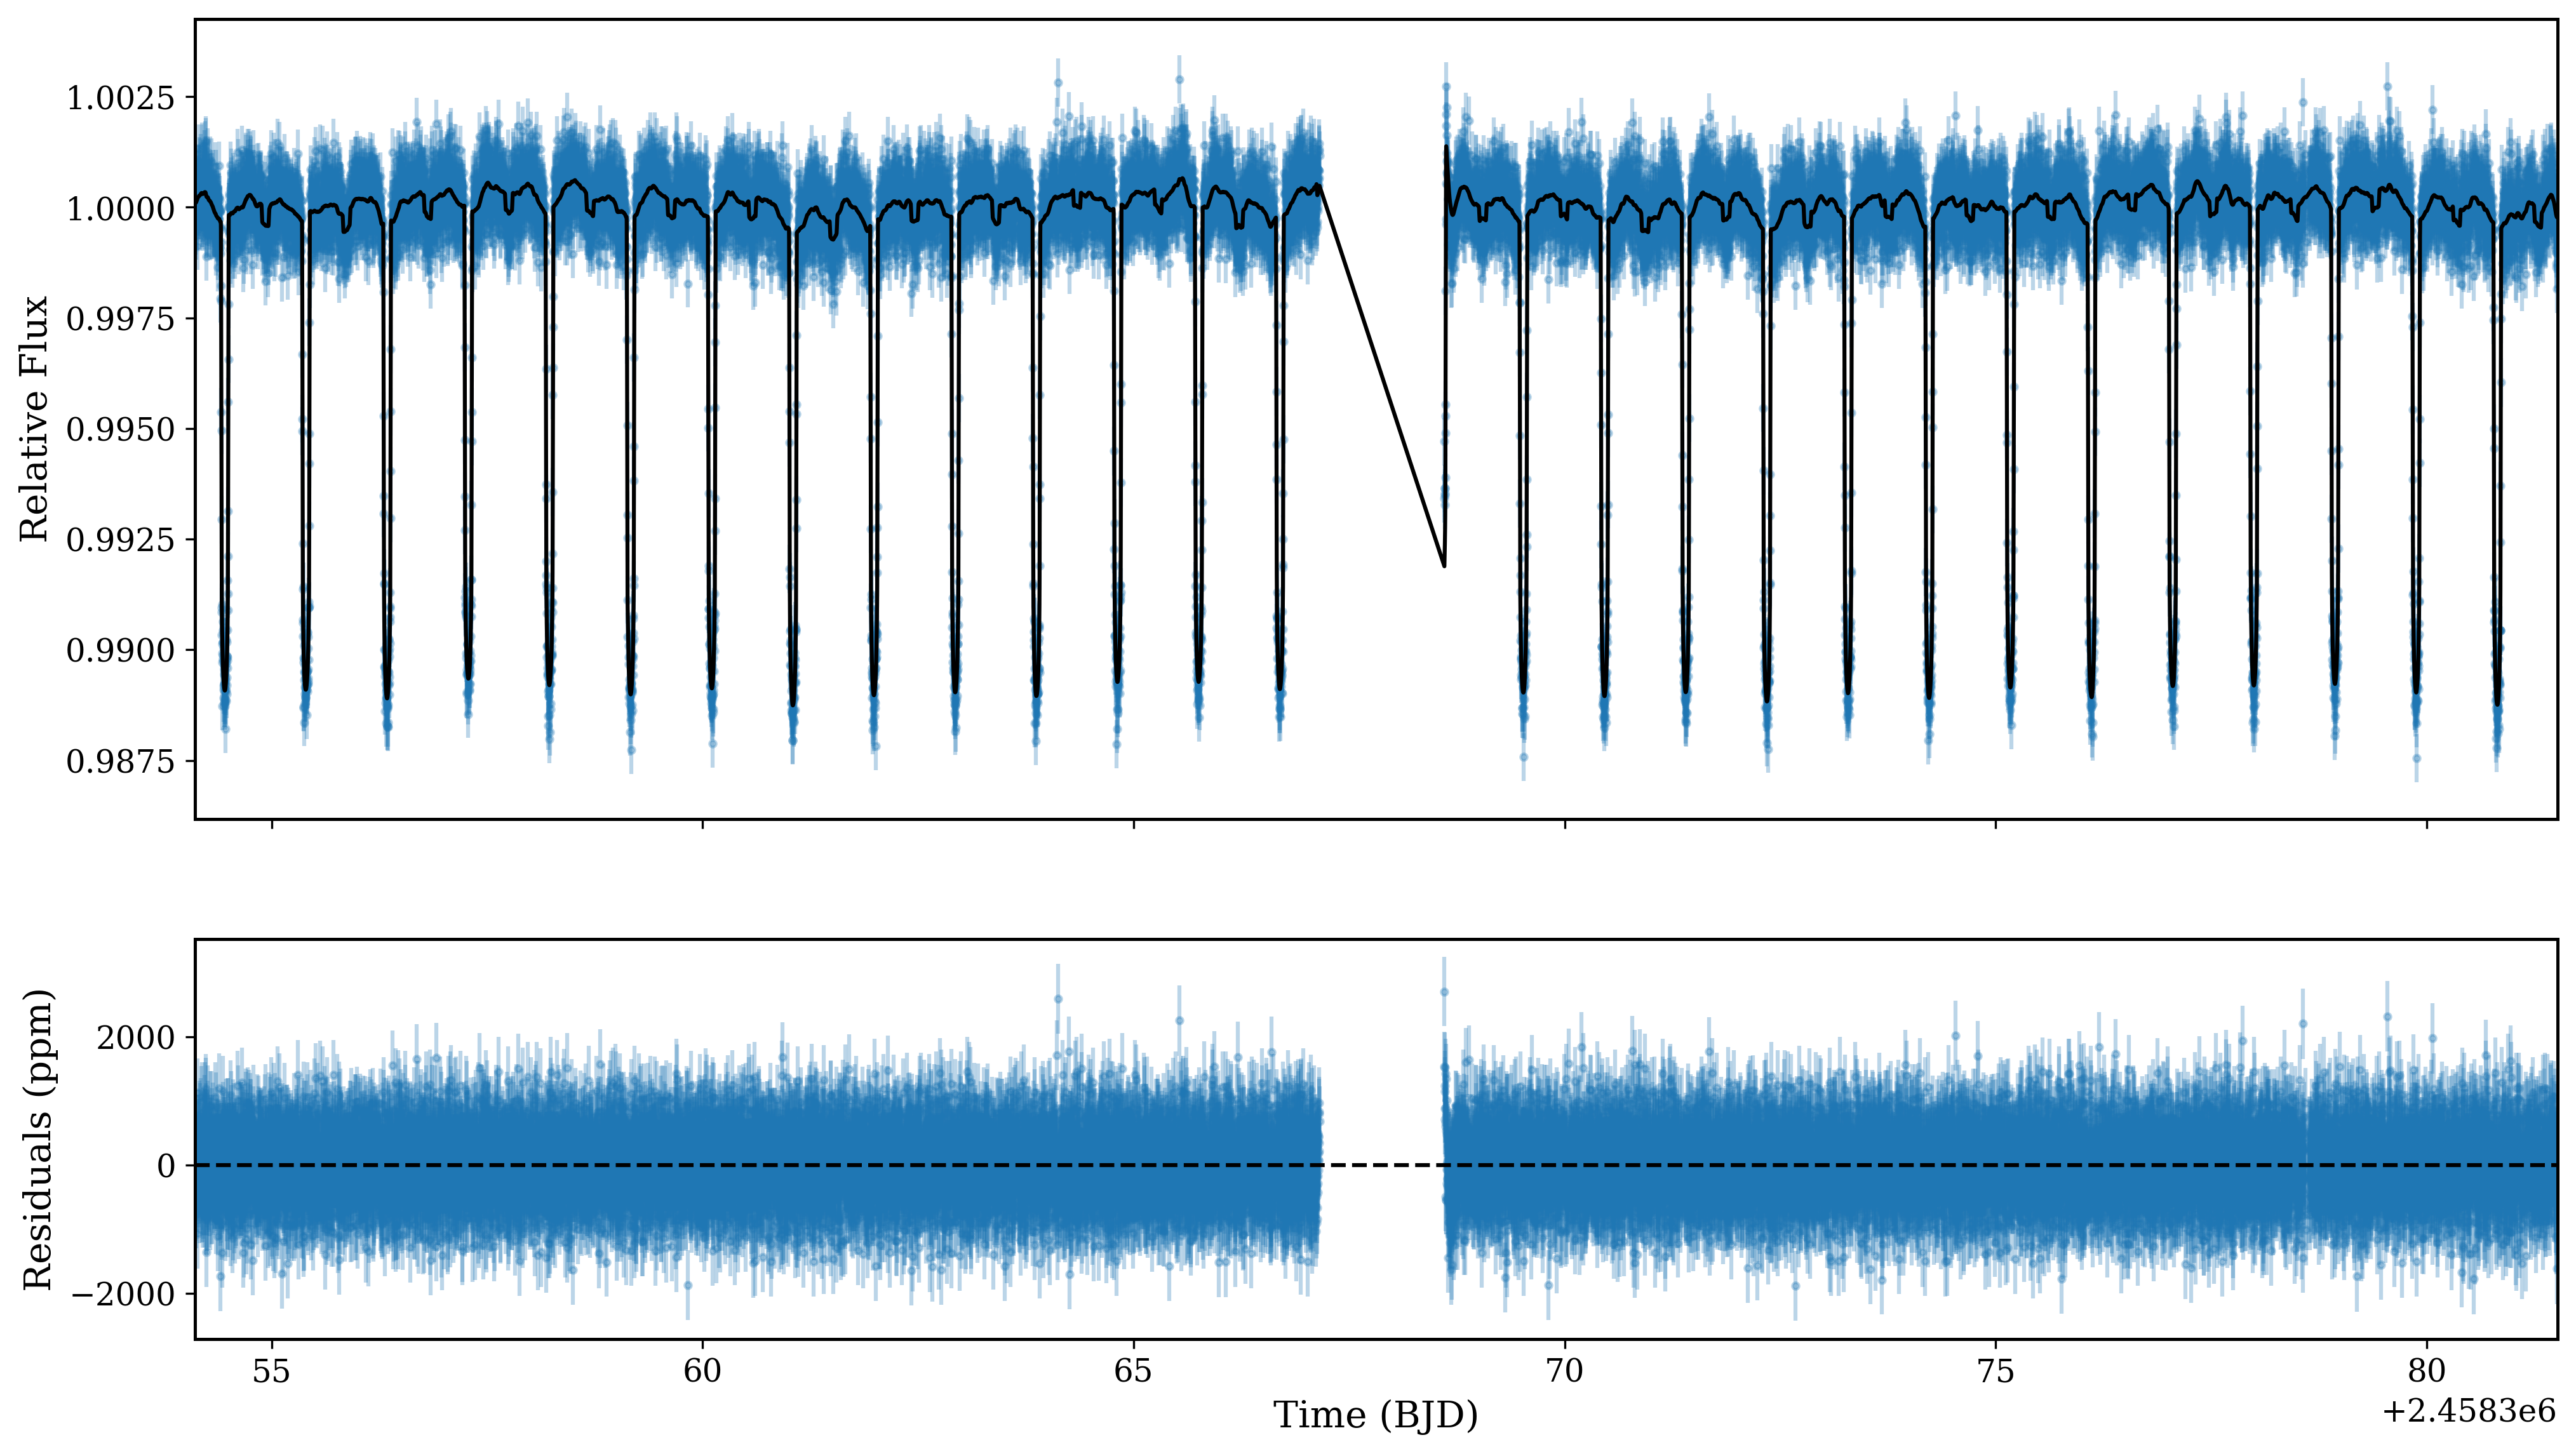

In [ ]:
# Making model
model = res.lc.evaluate('TESS2')
gp_model = res.lc.model['TESS2']['GP']
transit_model = res.lc.model['TESS2']['deterministic']
mflx = np.median(res.posteriors['posterior_samples']['mflux_TESS2'])
sigw = np.median(res.posteriors['posterior_samples']['sigma_w_TESS2'] * 1e-6)

fig = plt.figure(figsize=(16,9))
gs = gd.GridSpec(2,1, height_ratios=[2,1])

# Lightcurve
ax1 = plt.subplot(gs[0])
ax1.errorbar(tim['TESS2'], fl['TESS2'], yerr=fle['TESS2'], fmt='.', alpha=0.3)
ax1.plot(tim['TESS2'], model, c='k', zorder=100)
ax1.set_ylabel('Relative Flux')
ax1.set_xlim(np.min(tim['TESS2']), np.max(tim['TESS2']))
ax1.xaxis.set_major_formatter(plt.NullFormatter())
# fig.suptitle("WASP-18")

# Residual
ax2 = plt.subplot(gs[1])
ax2.errorbar(tim['TESS2'], (fl['TESS2']-model)*1e6, yerr=fle['TESS2']*1e6, fmt='.', alpha=0.3)
ax2.axhline(y=0.0, c='black', ls='--', zorder=100)
ax2.set_ylabel('Residuals (ppm)')
ax2.set_xlabel('Time (BJD)')
ax2.set_xlim(np.min(tim['TESS2']), np.max(tim['TESS2']))

### Zooming In (Circular case)

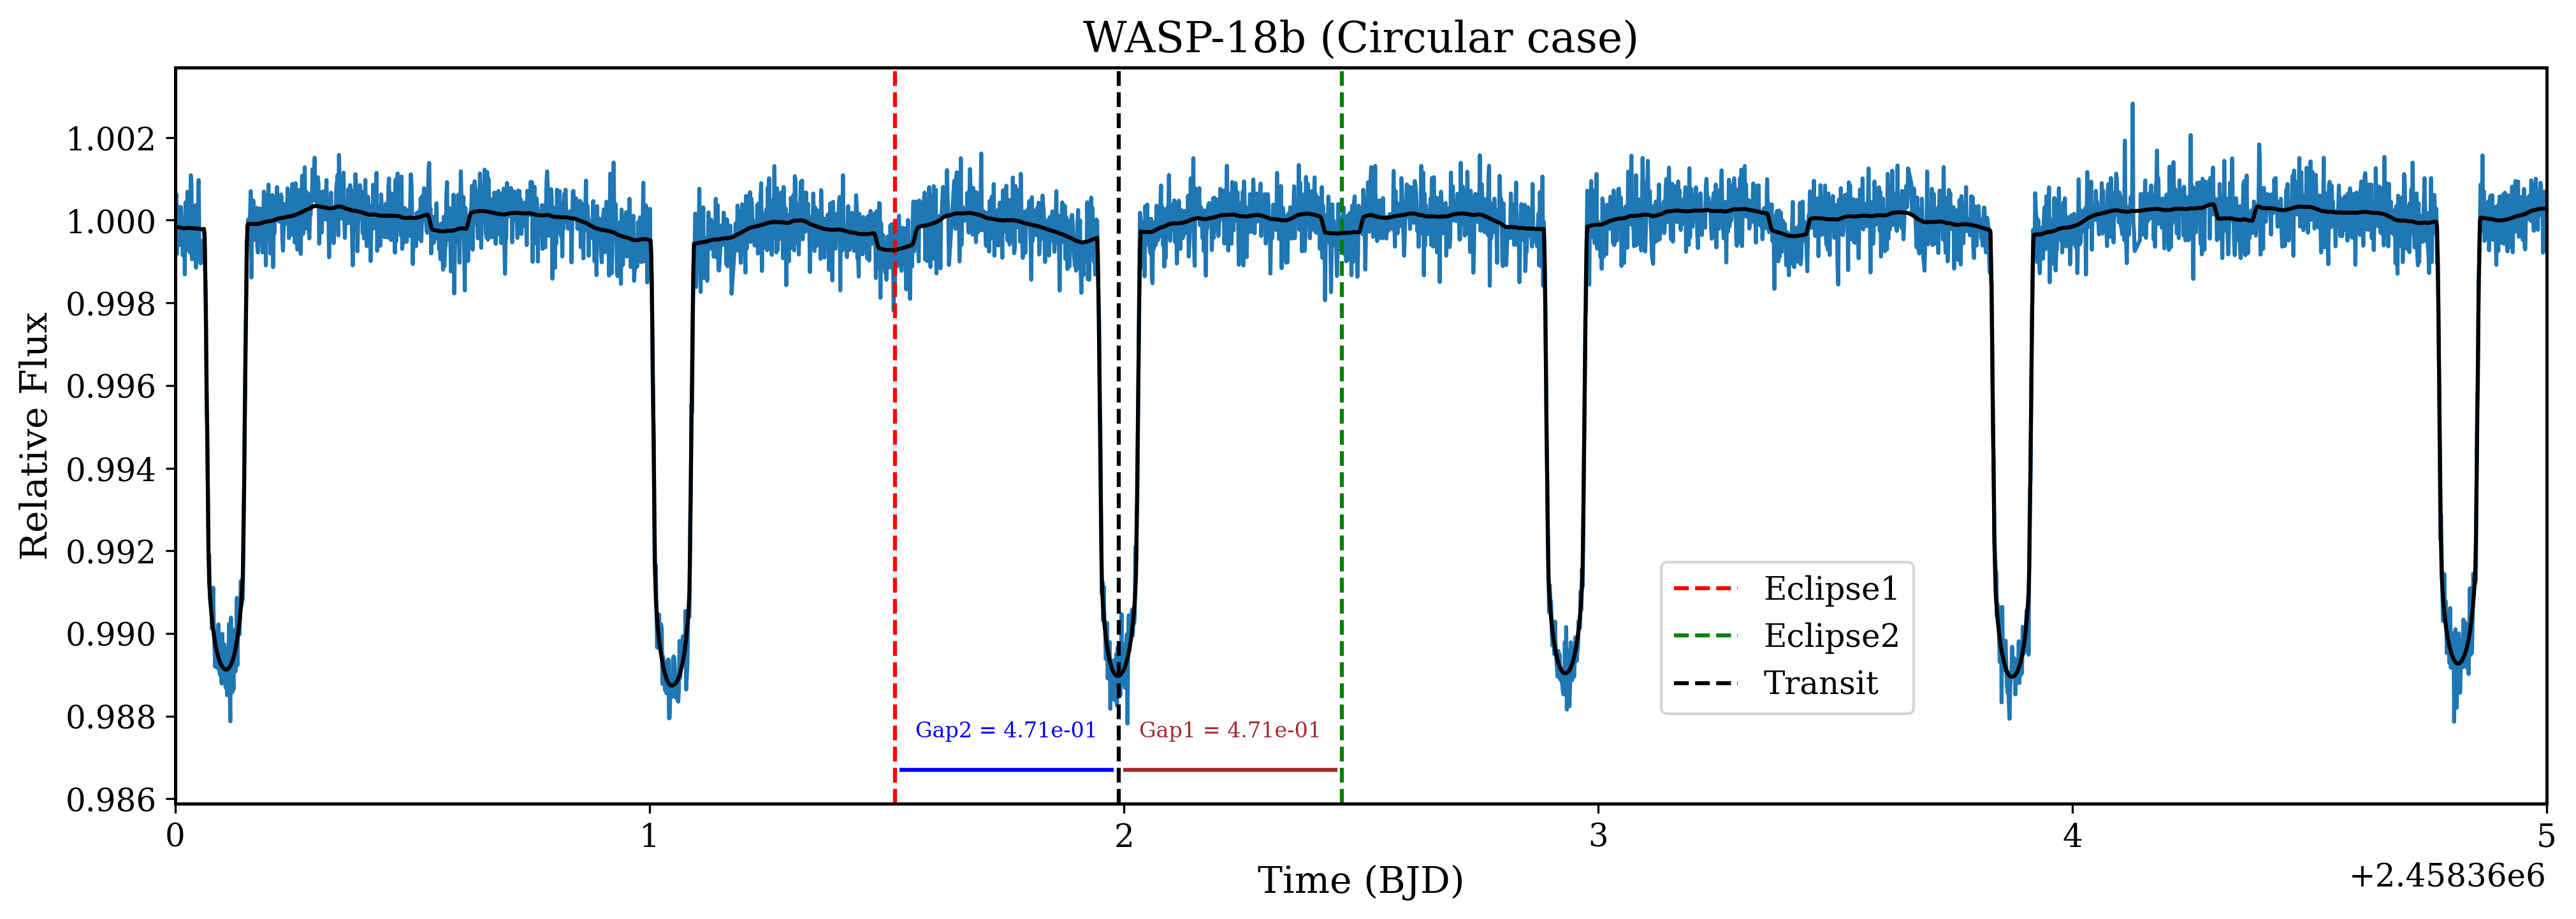

In [72]:
plt.figure(figsize=(16,5))
plt.plot(tim['TESS2'], model, c='k', zorder=100)
plt.plot(tim['TESS2'], fl['TESS2'])#, '.') #, yerr=fle['TESS2'], fmt='.', alpha=0.3)

tr1 = 1.9885 + 2.45836e6   # Transit
x1 = 1.517 + 2.45836e6  # Eclipse1   # red
x2 = 2.46 + 2.45836e6   # Eclipse2   # green
# xt = (x2 - x1)/2
y_gap2 = x2 - x1  # Choose a suitable y-coordinate for the horizontal line

gap2 = tr1 - x1
gap1 = x2 - tr1

# Plot vertical lines
plt.axvline(x=x1, color='red', linestyle='--', label="Eclipse1")
plt.axvline(x=x2, color='green', linestyle='--', label="Eclipse2")
plt.axvline(x=tr1, color='black', linestyle='--', label="Transit")

plt.hlines(y=0.9867, xmin=x1+0.01, xmax=tr1-0.01, color='blue', linestyle='-')#, label="Gap")
plt.text((x1 + tr1 ) / 2, 0.9865 + 0.001, f"Gap2 = {gap2:.2e}", color='blue', ha='center', fontsize=8)

plt.hlines(y=0.9867, xmin=tr1+0.01, xmax=x2-0.01, color='brown', linestyle='-')#, label="Gap")
plt.text((tr1 + x2) / 2, 0.9865 + 0.001, f"Gap1 = {gap1:.2e}", color='brown', ha='center', fontsize=8)

plt.xlim(60 + 2.4583e6, 65+ 2.4583e6)
plt.legend(loc="lower left", bbox_to_anchor=(0.62, 0.1))
plt.ylabel('Relative Flux')
plt.xlabel('Time (BJD)')
plt.title("WASP-18b (Circular case)")
plt.show()

In [ ]:
period = 0.9414522576 #   taken from the posterior obtained
e_cos_w = np.pi * (gap1/period - 0.5)
w = 158.9310344217 # from posterior
e = abs(e_cos_w / np.cos(w*np.pi/180))
print(f'e cos w = {e_cos_w}')     # 0.005919381140840311 (non zero ecc prior)  0.014261793666957933 (fixed 0 ecc)    
print(f'e = {e}')                 # 0.00634345104845027  (non zero ecc prior)  0.16363573090358577 (fixed 0 ecc)      
                                  # 0.00510 (Cortés-Zuleta et al. 2020),     0.00910 (Kokori et al. 2023)

e cos w = 0.0025824176842884155
e = 0.002767424461640659
